# 66 — LSEG Gemma/FinBERT backward-replication gate

**Question.** Can the unchanged Notebook 36 Gemma-timing/FinBERT-ranking strategy be tested on the earlier, non-overlapping 2024-01-01 to 2025-10-26 LSEG interval without reopening methodology after seeing returns?

**Current estimand.** This notebook has none in return space. It audits only acquisition checkpoints, complete cross-sectional dates, request density, storage capacity, and the predeclared Gemma measurement-stability design. Prices, returns, positions, and portfolio outcomes are deliberately absent.

**Scheduling amendment.** Day one collected company-major. Future resumptions collect date-major, reusing the same checkpoints, so progress converges toward a complete 33-company date prefix. The final frozen population is unchanged.

**Claim boundary.** The dashboard is operational evidence only. Its completion and storage projections are planning estimates, not signal or performance results. A later successful replay would be historical external-time corroboration, not prospective or deployment validation. The binding contract is `frozen_specs/lseg_gemma_finbert_hybrid_backward_v1.json`; dated amendments record the 10,000-request operational cap and date-major traversal.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

SEED = 20260806
ROOT = Path.cwd().resolve()
if not (ROOT / 'final_experiments').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.backward_validation import audit_backward_collection
from final_experiments.lib.plots import CATEGORICAL, INK, STATUS, annotate_source, apply_house_style

SPEC_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_v1.json'
OPERATIONAL_AMENDMENT_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_operational_amendment_20260806.json'
ORDER_AMENDMENT_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_collection_order_amendment_20260806.json'
OPERATIONAL_DAILY_REQUEST_BUDGET = 10_000
for required_path in (SPEC_PATH, OPERATIONAL_AMENDMENT_PATH, ORDER_AMENDMENT_PATH):
    assert required_path.is_file(), required_path

apply_house_style()
plt.rcParams['axes.titleweight'] = 'normal'
pd.set_option('display.max_colwidth', 110)
ROOT

PosixPath('/Users/peterprendergast/Documents/Sentiment_Dissertation')

## Frozen stage order

1. Complete and hash the same-33 headline collection. The source config retains its 9,500-request identity default; the dated operational amendment permits up to 10,000 requests on a normal reset day.
2. Resume date-major: finish every missing company for the earliest date before advancing. Existing AAPL/MSFT/NVDA checkpoints remain valid and are never fetched again.
3. Normalize and deduplicate headlines without market data.
4. Re-score the frozen Gemma drift sample and require every stability threshold.
5. Score the complete new population with the unchanged Gemma and FinBERT contracts.
6. Build firm-open signals without prices and require 120 complete sessions, 60 active sessions, and 20 active sessions per half.
7. Only then may a separate one-shot return replay load prices.

A partial batch can answer only whether acquisition is healthy, how much complete cross-sectional history exists, and whether quota/storage planning remains feasible. It cannot answer whether the strategy works.

In [2]:
collection_audit = audit_backward_collection(
    ROOT,
    SPEC_PATH,
    daily_request_budget=OPERATIONAL_DAILY_REQUEST_BUDGET,
)
progress = collection_audit.summary.iloc[0]
date_progress = collection_audit.date_progress.copy()
projection = collection_audit.projection.iloc[0]

progress_columns = [
    'status', 'companies', 'windows_per_company', 'completed_windows', 'expected_windows',
    'window_completion_pct', 'headline_pages', 'complete_dates', 'complete_date_prefix',
    'partial_dates', 'untouched_dates', 'frontier_date', 'frontier_companies_completed',
    'pagination_anomalies',
]
display(collection_audit.summary[progress_columns])

projection_metrics = pd.DataFrame(
    [
        ('projection basis', projection['projection_basis']),
        ('daily request budget', f"{int(projection['daily_request_budget']):,}"),
        ('requests / completed company-window', f"{projection['observed_requests_per_completed_company_window']:.2f}"),
        (
            'requests / complete 33-company date',
            'not available yet'
            if pd.isna(projection['observed_requests_per_complete_date'])
            else f"{projection['observed_requests_per_complete_date']:.2f}",
        ),
        ('minimum remaining requests', f"{int(projection['minimum_remaining_requests']):,}"),
        ('estimated remaining requests', f"{int(projection['estimated_remaining_requests']):,}"),
        ('estimated remaining full-quota days', f"{int(projection['estimated_remaining_quota_days'])}"),
        ('current raw collection', f"{projection['current_raw_storage_gib']:.2f} GiB"),
        ('projected additional storage', f"{projection['projected_additional_storage_gib']:.2f} GiB"),
        ('free disk now', f"{projection['free_disk_gib']:.2f} GiB"),
        ('projected disk headroom', f"{projection['projected_free_after_completion_gib']:.2f} GiB"),
    ],
    columns=['metric', 'value'],
)
display(projection_metrics)
display(collection_audit.gate_table)
collection_audit.collection_gate_pass

,status,companies,windows_per_company,completed_windows,expected_windows,window_completion_pct,headline_pages,complete_dates,complete_date_prefix,partial_dates,untouched_dates,frontier_date,frontier_companies_completed,pagination_anomalies
0,in_progress,33,664,1469,21912,6.704089,4841,0,0,664,0,2024-01-01T00:00:00Z,3,0


,metric,value
0,projection basis,mean page requests per completed company-window; company-biased until the first complete date
1,daily request budget,"10,000"
2,requests / completed company-window,3.30
3,requests / complete 33-company date,not available yet
4,minimum remaining requests,"20,443"
5,estimated remaining requests,"67,369"
6,estimated remaining full-quota days,7
7,current raw collection,1.66 GiB
8,projected additional storage,23.17 GiB
9,free disk now,31.87 GiB


,gate,passed
0,manifest_completed,False
1,all_company_windows_completed,False
2,headline_file_hash_matches,False
3,empty_story_file_hash_matches,False
4,no_unsafe_pagination_anomalies,True
5,headline_only_zero_stories,False
6,collection_ready_for_drift_audit,False


False

## Date-major acquisition dashboard

The first panel distinguishes a **complete date** (all 33 company windows terminal) from a merely touched date. The frontier is the first date after the contiguous complete prefix. Page checkpoints equal headline-page API requests, so the second panel shows the quota load by date without opening headline text.

Until the first complete 33-company date exists, the completion projection uses page density from the already completed AAPL/MSFT/NVDA windows. That is intentionally labelled company-biased and should be treated as a conservative planning estimate rather than a stable forecast.

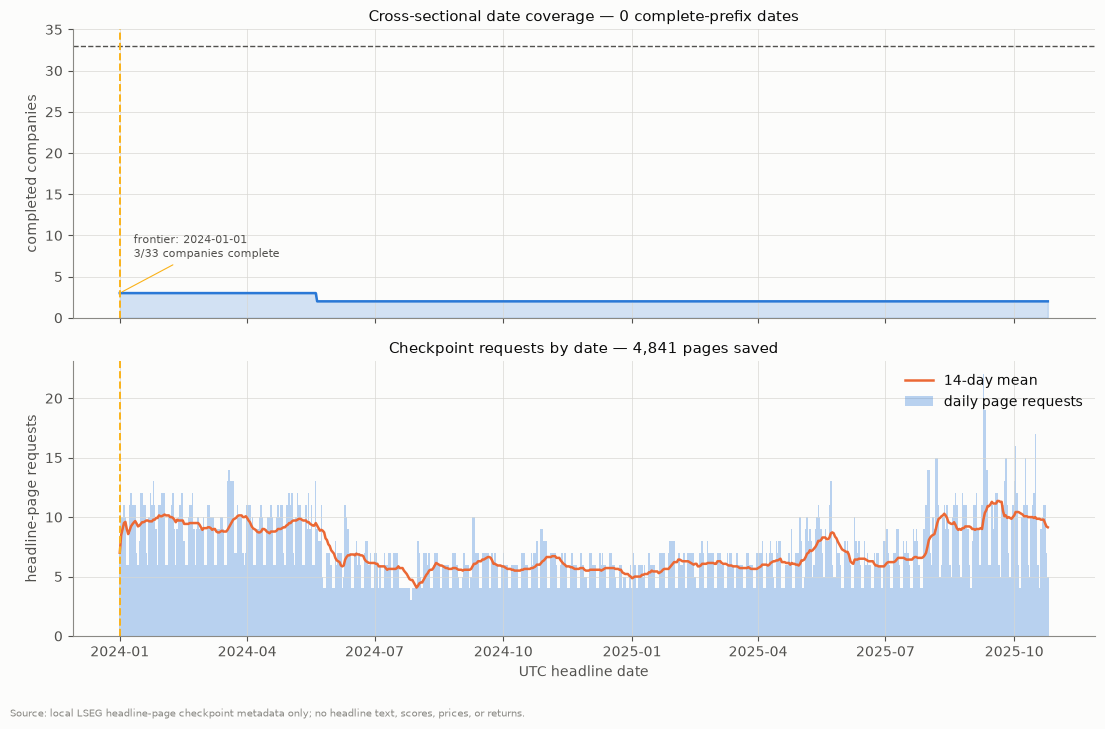

In [3]:
date_progress['date'] = pd.to_datetime(date_progress['window_start'], utc=True)
frontier_position = int(progress['complete_date_prefix'])
frontier_date = (
    date_progress.iloc[frontier_position]['date']
    if frontier_position < len(date_progress)
    else None
)

fig, (ax_coverage, ax_requests) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [1.05, 1.0]},
)

ax_coverage.fill_between(
    date_progress['date'],
    date_progress['completed_companies'],
    step='mid',
    color=CATEGORICAL[0],
    alpha=0.20,
)
ax_coverage.plot(
    date_progress['date'],
    date_progress['completed_companies'],
    color=CATEGORICAL[0],
    lw=1.8,
)
ax_coverage.axhline(33, color=INK['reference'], lw=1.0, ls='--')
if frontier_date is not None:
    ax_coverage.axvline(frontier_date, color=STATUS['warning'], lw=1.4, ls='--')
    ax_coverage.annotate(
        f"frontier: {frontier_date.date().isoformat()}\n"
        f"{int(progress['frontier_companies_completed'])}/33 companies complete",
        xy=(frontier_date, int(progress['frontier_companies_completed'])),
        xytext=(10, 26),
        textcoords='offset points',
        fontsize=8,
        color=INK['secondary'],
        arrowprops={'arrowstyle': '-', 'color': STATUS['warning'], 'lw': 0.8},
    )
ax_coverage.set_ylim(0, 35)
ax_coverage.set_ylabel('completed companies')
ax_coverage.set_title(
    f"Cross-sectional date coverage — {int(progress['complete_date_prefix']):,} complete-prefix dates"
)

rolling_requests = date_progress['page_requests'].rolling(14, min_periods=1).mean()
ax_requests.bar(
    date_progress['date'],
    date_progress['page_requests'],
    width=1.0,
    color=CATEGORICAL[0],
    alpha=0.32,
    label='daily page requests',
)
ax_requests.plot(
    date_progress['date'],
    rolling_requests,
    color=CATEGORICAL[1],
    lw=1.8,
    label='14-day mean',
)
if frontier_date is not None:
    ax_requests.axvline(frontier_date, color=STATUS['warning'], lw=1.4, ls='--')
ax_requests.set_ylabel('headline-page requests')
ax_requests.set_xlabel('UTC headline date')
ax_requests.set_title(f"Checkpoint requests by date — {int(progress['headline_pages']):,} pages saved")
ax_requests.legend(loc='upper right')

annotate_source(
    fig,
    'Source: local LSEG headline-page checkpoint metadata only; no headline text, scores, prices, or returns.',
)
fig.tight_layout()
plt.show()

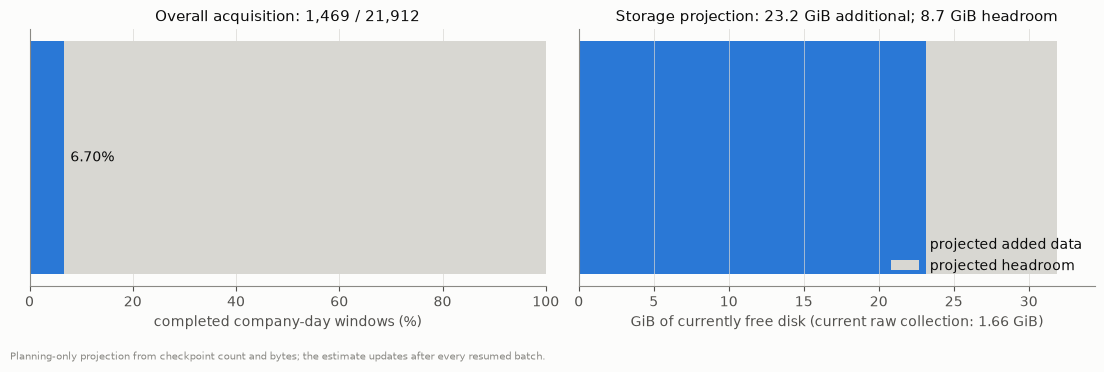

In [4]:
pct = float(progress['window_completion_pct'])
free_gib = float(projection['free_disk_gib'])
additional_gib = float(projection['projected_additional_storage_gib'])
headroom_gib = float(projection['projected_free_after_completion_gib'])

fig, (ax_windows, ax_storage) = plt.subplots(1, 2, figsize=(11, 3.5))

ax_windows.barh([0], [100.0], color=INK['grid'])
ax_windows.barh([0], [pct], color=CATEGORICAL[0])
ax_windows.set_xlim(0, 100)
ax_windows.set_yticks([])
ax_windows.set_xlabel('completed company-day windows (%)')
ax_windows.set_title(
    f"Overall acquisition: {int(progress['completed_windows']):,} / {int(progress['expected_windows']):,}"
)
ax_windows.text(min(pct + 1.2, 94), 0, f"{pct:.2f}%", va='center', color=INK['primary'])

if headroom_gib >= 0:
    ax_storage.barh([0], [additional_gib], color=CATEGORICAL[0], label='projected added data')
    ax_storage.barh(
        [0],
        [headroom_gib],
        left=[additional_gib],
        color=INK['grid'],
        label='projected headroom',
    )
else:
    ax_storage.barh([0], [free_gib], color=STATUS['critical'], alpha=0.35, label='free disk')
    ax_storage.barh([0], [additional_gib], color=STATUS['critical'], alpha=0.75, label='projected need')
ax_storage.set_xlim(0, max(free_gib, additional_gib, 1.0) * 1.08)
ax_storage.set_yticks([])
ax_storage.set_xlabel(
    f"GiB of currently free disk (current raw collection: {projection['current_raw_storage_gib']:.2f} GiB)"
)
ax_storage.set_title(
    f"Storage projection: {additional_gib:.1f} GiB additional; {headroom_gib:.1f} GiB headroom"
)
ax_storage.legend(loc='lower right')

annotate_source(
    fig,
    'Planning-only projection from checkpoint count and bytes; the estimate updates after every resumed batch.',
)
fig.tight_layout()
plt.show()

In [5]:
frontier_start = max(frontier_position - 2, 0)
frontier_stop = min(frontier_position + 5, len(date_progress))
frontier_view = date_progress.iloc[frontier_start:frontier_stop].copy()
frontier_view['date'] = frontier_view['date'].dt.date.astype(str)
display(
    frontier_view[
        ['window_index', 'date', 'completed_companies', 'expected_companies', 'complete_date', 'page_requests', 'checkpoint_mib']
    ].round({'checkpoint_mib': 2})
)

storage_status = (
    'RED_FLAG: projected completion exceeds currently free disk'
    if projection['projected_free_after_completion_gib'] < 0
    else (
        'WARNING: projected headroom is below 10 GiB'
        if projection['projected_free_after_completion_gib'] < 10
        else 'adequate under the current planning estimate'
    )
)
frontier_companies_completed = (
    None
    if pd.isna(progress['frontier_companies_completed'])
    else int(progress['frontier_companies_completed'])
)
operational_decision = {
    'complete_33_company_dates': int(progress['complete_dates']),
    'contiguous_complete_prefix_dates': int(progress['complete_date_prefix']),
    'frontier_date': progress['frontier_date'],
    'frontier_companies_completed': frontier_companies_completed,
    'estimated_remaining_full_quota_days': int(projection['estimated_remaining_quota_days']),
    'storage_status': storage_status,
    'scores_prices_or_returns_loaded': False,
}
assert operational_decision['scores_prices_or_returns_loaded'] is False
operational_decision

,window_index,date,completed_companies,expected_companies,complete_date,page_requests,checkpoint_mib
0,1,2024-01-01,3,33,False,7,1.70
1,2,2024-01-02,3,33,False,10,3.72
2,3,2024-01-03,3,33,False,10,4.13
3,4,2024-01-04,3,33,False,11,4.56
4,5,2024-01-05,3,33,False,10,3.89


{'complete_33_company_dates': 0,
 'contiguous_complete_prefix_dates': 0,
 'frontier_date': '2024-01-01T00:00:00Z',
 'frontier_companies_completed': 3,
 'estimated_remaining_full_quota_days': 7,
 'storage_status': 'WARNING: projected headroom is below 10 GiB',
 'scores_prices_or_returns_loaded': False}

## Gemma measurement-drift gate

The strategy's event clock depends on Gemma returning an exact signed score of +1 or -1. Hosted model names and provider pins do not cryptographically pin weights, so a fresh historical score population is not comparable until the endpoint behaviour is rechecked.

The frozen sample is return-blind: all 774 exact endpoints in the completed 888,155-headline reference file, plus 1,000 non-endpoints chosen by deterministic hash order. No headline or score is selected using a stock return. Drift failure stops the arm; it does not license a new threshold.

In [6]:
spec = json.loads(SPEC_PATH.read_text(encoding='utf-8'))
drift = spec['gemma_model_drift_gate']
drift_design = pd.DataFrame(
    [
        {'metric': 'continuous Spearman', 'pass rule': f">= {drift['continuous_spearman_minimum']:.2f}"},
        {'metric': 'mean absolute score difference', 'pass rule': f"<= {drift['continuous_mean_absolute_difference_maximum']:.2f}"},
        {'metric': 'direction agreement', 'pass rule': f">= {drift['direction_agreement_minimum']:.2%}"},
        {'metric': 'same exact endpoint and direction retained', 'pass rule': f">= {drift['endpoint_same_direction_retention_minimum']:.2%}"},
        {'metric': 'endpoint reversed to opposite direction', 'pass rule': f"<= {drift['endpoint_opposite_direction_count_maximum']} rows"},
        {'metric': 'non-endpoint becomes exact endpoint', 'pass rule': f"<= {drift['nonendpoint_to_endpoint_rate_maximum']:.2%}"},
    ]
)
display(drift_design)
{'endpoint_census': 774, 'nonendpoint_controls': 1000, 'paid_drift_scoring_authorised': False}

,metric,pass rule
0,continuous Spearman,>= 0.95
1,mean absolute score difference,<= 0.10
2,direction agreement,>= 90.00%
3,same exact endpoint and direction retained,>= 80.00%
4,endpoint reversed to opposite direction,<= 0 rows
5,non-endpoint becomes exact endpoint,<= 5.00%


{'endpoint_census': 774,
 'nonendpoint_controls': 1000,
 'paid_drift_scoring_authorised': False}

## Predeclared one-shot methodology after the gates

The primary replay inherits the exact strongest-event collision rule, Gemma endpoint dates/counts, FinBERT within-session ranking, equal leg weights, 25% name cap, gross limit 1, dollar neutrality, cash for unused capacity, next-open holding interval, drift-aware turnover, final liquidation, and 10 bps per traded side. It will report gross and net Sharpe, return, turnover, drawdown, break-even cost, block-bootstrap cash inference, HAC market-plus-sector alpha, chronological halves, and rebuilt company/sector exclusions.

Two non-promoting mechanism tests form one BH family: circular shifts of Gemma's full date/count schedule, and same-session matched-count random-name assignments. These distinguish event timing from FinBERT name selection but cannot rescue a failed primary gate.

In [7]:
storage_headroom_gib = float(projection['projected_free_after_completion_gib'])
decision = {
    'collection_status': progress['status'],
    'collection_gate_pass': bool(collection_audit.collection_gate_pass),
    'complete_date_prefix': int(progress['complete_date_prefix']),
    'frontier_date': progress['frontier_date'],
    'estimated_remaining_full_quota_days': int(projection['estimated_remaining_quota_days']),
    'projected_storage_headroom_gib': storage_headroom_gib,
    'drift_scoring_authorised': False,
    'prices_or_returns_loaded': False,
    'next_action': (
        'prepare frozen drift sample and request paid-scoring approval'
        if collection_audit.collection_gate_pass
        else (
            'free or relocate storage, then continue the immutable date-major headline collection'
            if storage_headroom_gib < 10
            else 'continue the immutable date-major headline collection at the next quota reset'
        )
    ),
}
assert decision['prices_or_returns_loaded'] is False
decision

{'collection_status': 'in_progress',
 'collection_gate_pass': False,
 'complete_date_prefix': 0,
 'frontier_date': '2024-01-01T00:00:00Z',
 'estimated_remaining_full_quota_days': 7,
 'projected_storage_headroom_gib': 8.703237709212235,
 'drift_scoring_authorised': False,
 'prices_or_returns_loaded': False,
 'next_action': 'free or relocate storage, then continue the immutable date-major headline collection'}